#**MIS 311 - Dataset #7 - Most visited countries**




Hi there,

I’m the host of a movie reviews podcast and I’m currently making an episode about movie review aggregators.

I found this data set from Rotten Tomatoes (inside the .ipynb file that I’ve attached). Could you dig into the data and share any interesting insights that you find? My audience loves fun facts about movies.

Thank you!\
NB

##**0. Read in the Data**

In [ ]:
# Import nescessary library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("07_Most Visited Countries.xlsx")

##**1. Data Overview**

In [ ]:
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Data Info ---")
print(df.info())

--- Dataset Shape ---
(206, 6)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   country                                            206 non-null    object 
 1   MostVisited_NumOfArrivalsPredictive_Millions_2024  50 non-null     float64
 2   MostVisited_NumOfArrivals_Millions_2023            49 non-null     float64
 3   MostVisited_NumOfArrivals_Millions_2022            20 non-null     float64
 4   MostVisited_NumOfArrivals_WorldBank                205 non-null    float64
 5   MostVisited_DataYear_WorldBank                     205 non-null    float64
dtypes: float64(5), object(1)
memory usage: 9.8+ KB
None


##**2. Data Cleaning**: Check for duplicates

In [ ]:
print("\n--- Duplicate Rows Before Cleaning ---")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates successfully removed!")
else:
    print("No duplicates to remove.")


--- Duplicate Rows Before Cleaning ---
Number of duplicate rows found: 3
Duplicates successfully removed!


##**2. Data Cleaning**: Check for missing values

In [ ]:
print("\n--- Missing Values Per Column Before Cleaning ---")
print(df.isnull().sum())
if df.isnull().sum().sum() > 0:
  df = df.dropna()
  print("Rows with missing values successfully dropped!")
else:
  print("No missing values found. Dataset is clean!")


--- Missing Values Per Column Before Cleaning ---
country                                                0
MostVisited_NumOfArrivalsPredictive_Millions_2024    153
MostVisited_NumOfArrivals_Millions_2023              154
MostVisited_NumOfArrivals_Millions_2022              183
MostVisited_NumOfArrivals_WorldBank                    1
MostVisited_DataYear_WorldBank                         1
dtype: int64
Rows with missing values successfully dropped!


##**3. Descriptive Statistics**

In [ ]:
# Summary statistics for the numerical columns
print("\n--- Descriptive Statistics ---")
print(df[['MostVisited_NumOfArrivals_Millions_2022',
          'MostVisited_NumOfArrivals_Millions_2023',
          'MostVisited_NumOfArrivalsPredictive_Millions_2024']].describe())


--- Descriptive Statistics ---
       MostVisited_NumOfArrivals_Millions_2022  \
count                                17.000000   
mean                                 31.412941   
std                                  20.429135   
min                                  11.660000   
25%                                  16.070000   
50%                                  26.210000   
75%                                  38.330000   
max                                  79.400000   

       MostVisited_NumOfArrivals_Millions_2023  \
count                                17.000000   
mean                                 38.488235   
std                                  24.894484   
min                                  12.930000   
25%                                  20.300000   
50%                                  30.910000   
75%                                  42.150000   
max                                 100.000000   

       MostVisited_NumOfArrivalsPredictive_Millions_2024  
count  

##**Finding Key Insights**

##Insight 1

Total Arrivals (Millions): 
2022: 534.02
2023: 654.30
2024 (Pred): 651.50


/tmp/ipykernel_675/1930979759.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=years, y=totals, palette='viridis')


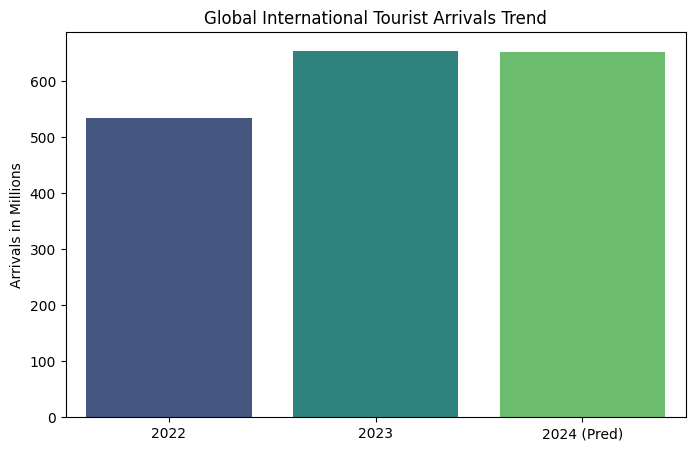

In [ ]:
# Calculate total arrivals by year
total_2022 = df['MostVisited_NumOfArrivals_Millions_2022'].sum()
total_2023 = df['MostVisited_NumOfArrivals_Millions_2023'].sum()
total_2024 = df['MostVisited_NumOfArrivalsPredictive_Millions_2024'].sum()

print(f"Total Arrivals (Millions): \n2022: {total_2022:.2f}\n2023: {total_2023:.2f}\n2024 (Pred): {total_2024:.2f}")

# Plot the trend
years = ['2022', '2023', '2024 (Pred)']
totals = [total_2022, total_2023, total_2024]

plt.figure(figsize=(8, 5))
sns.barplot(x=years, y=totals, palette='viridis')
plt.title('Global International Tourist Arrivals Trend')
plt.ylabel('Arrivals in Millions')
plt.show()

--> The descriptive statistics show a massive surge in global international tourist arrivals between 2022 and 2023, jumping from roughly 530 million to over 650 million arrivals. Following this aggressive recovery period, the predictive data for 2024 shows a plateauing trend, with volume remaining relatively flat compared to the previous year. For business analytics and market forecasting, this indicates that the post-pandemic travel boom has officially normalized, shifting the market into a stable, highly predictable baseline for operational planning.

##Insight 2

/tmp/ipykernel_675/1125875505.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='MostVisited_NumOfArrivals_Millions_2023', y='country', palette='plasma')


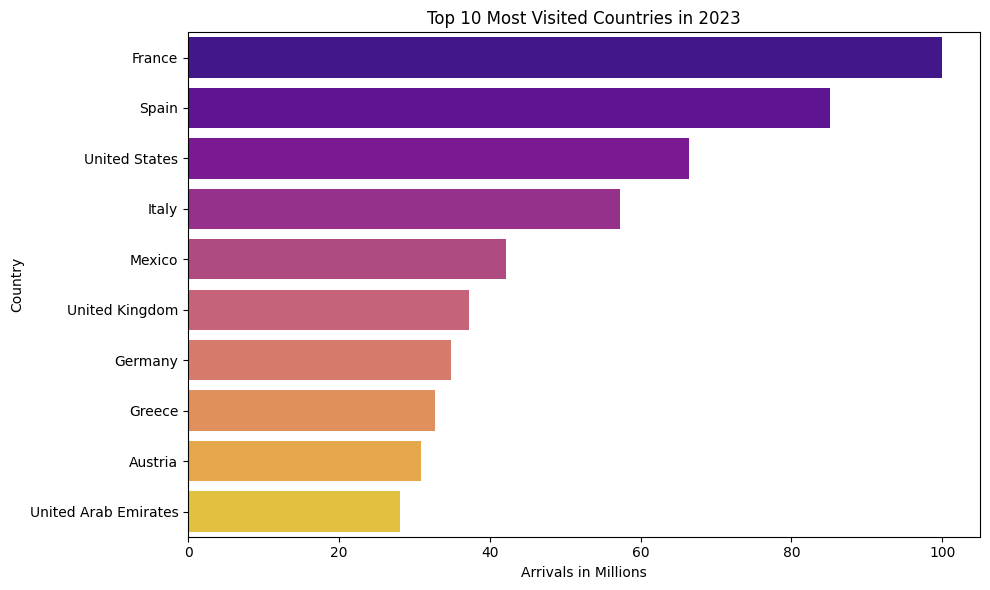

In [ ]:
# Sort by 2023 arrivals to find top destinations
top_10 = df.sort_values(by='MostVisited_NumOfArrivals_Millions_2023', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x='MostVisited_NumOfArrivals_Millions_2023', y='country', palette='plasma')
plt.title('Top 10 Most Visited Countries in 2023')
plt.xlabel('Arrivals in Millions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

--> The descriptive statistics reveal a heavy concentration of global tourism demand within a few elite destinations, with France leading the global market at 100 million international arrivals in 2023, closely followed by Spain at approximately 85 million. European nations heavily dominate the top ten tier, capturing six out of the ten spots and proving that Western and Mediterranean Europe remain the primary epicenters for international travel infrastructure. For business analysts in the hospitality, aviation, and retail sectors, this highlights specific high-density geographic markets where resource allocation and expansion campaigns yield the most reliable commercial returns.